# 🏦 ATM & POS Transaction Data Science Analysis

## 📊 Executive Summary
This notebook presents an advanced Data Science approach to analyzing ATM and POS terminal performance across various districts. 
The primary objective is to cluster terminals based on transaction volume, transaction value, and **failure rates** to provide actionable business recommendations (e.g., Identifying terminals that need immediate maintenance vs. terminals that are highly reliable).

**Confidentiality Notice:** All proprietary bank names, products, and internal acronyms have been systematically anonymized to maintain institutional confidentiality.

## 1. Setup & Data Loading
In this section, we load the required libraries and the datasets. We also apply a strict anonymization pipeline to ensure no sensitive institutional names are exposed in the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Define Data Paths
base_dir = r"."
pos_path = os.path.join(base_dir, 'pos_NEW1.xlsx')
atm_path = os.path.join(base_dir, 'ATM24_25 full.xlsx')

# Load Datasets
pos_df = pd.read_excel(pos_path)
atm_df = pd.read_excel(atm_path)

# Drop rows missing crucial identifiers
pos_df = pos_df.dropna(subset=['BRANCHNAME', 'DISTRICTNAME', 'TERMINAL_ID'])
atm_df = atm_df.dropna(subset=['BRANCHNAME', 'DISTRICTNAME', 'TERMINAL_ID'])

# Standardize Columns
atm_df.columns = atm_df.columns.str.upper()
pos_df.columns = pos_df.columns.str.upper()

print(f"Loaded {len(atm_df)} ATM records and {len(pos_df)} POS records.")

Loaded 208839 ATM records and 107097 POS records.


## 🔐 1.1 Data Anonymization Pipeline
To ensure confidentiality, we will dynamically search through categorical columns and replace specific internal names (e.g., 'CBE', 'CBEBIRR') with generic financial terms (e.g., 'BANK', 'MOBILE_WALLET').

In [2]:
def anonymize_data(df):
    df = df.copy()
    # Replace known proprietary strings in all object columns
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).str.replace(r'(?i)cbebirr', 'MOBILE_WALLET', regex=True)
        df[col] = df[col].astype(str).str.replace(r'(?i)cbe', 'BANK', regex=True)
    return df

atm_df = anonymize_data(atm_df)
pos_df = anonymize_data(pos_df)

print("✅ Data successfully anonymized.")

✅ Data successfully anonymized.


## 2. ATM Terminal Analysis & Insights
Here we explore the basic performance of the ATM network.

## 2.2 Compare Districts vs. Daily Mean Threshold
We have confirmed that this dataset covers an annual period. We calculate the Average Daily Transactions per ATM terminal for each district by dividing the total yearly transactions by 365. We then compare each district's performance against the overall mean threshold.

Overall average daily transaction threshold: 276.12


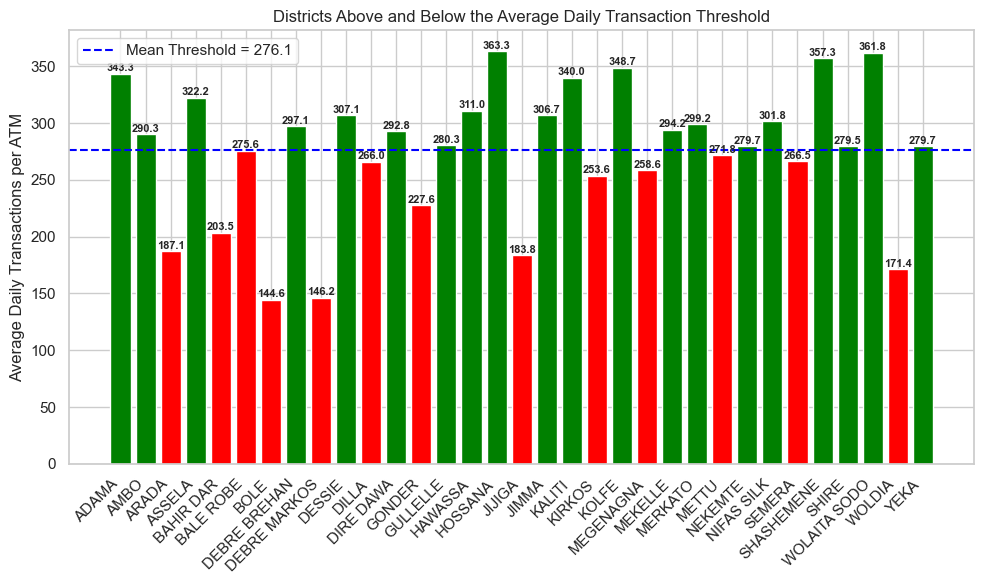

In [3]:
# Step 1: Calculate district-level average daily transactions (assuming 365 days)
avg_daily_txn_district = (
    atm_df.groupby(['DISTRICTNAME', 'TERMINAL_ID'])['NO_TXN']
    .sum()
    .div(365)  # Convert yearly total to daily average
    .groupby('DISTRICTNAME')
    .mean()
    .reset_index(name='AVG_DAILY_TXN')
)

# Step 2: Use the overall mean as the threshold
min_threshold = avg_daily_txn_district['AVG_DAILY_TXN'].mean()
print(f"Overall average daily transaction threshold: {min_threshold:.2f}")

# Step 3: Flag districts below threshold
avg_daily_txn_district['BELOW_THRESHOLD'] = avg_daily_txn_district['AVG_DAILY_TXN'] < min_threshold

# Step 4: Create color coding based on threshold
colors = ['red' if val < min_threshold else 'green' for val in avg_daily_txn_district['AVG_DAILY_TXN']]

# Step 5: Plot bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(avg_daily_txn_district['DISTRICTNAME'], avg_daily_txn_district['AVG_DAILY_TXN'], color=colors)

# Draw horizontal threshold line
plt.axhline(min_threshold, color='blue', linestyle='--', linewidth=1.5, label=f'Mean Threshold = {min_threshold:.1f}')

# Annotate each bar with its value
for i, v in enumerate(avg_daily_txn_district['AVG_DAILY_TXN']):
    ax.text(i, v + 0.3, f"{v:.1f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.ylabel("Average Daily Transactions per ATM")
plt.title("Districts Above and Below the Average Daily Transaction Threshold")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 2.1 ATM Failure Diagnostics
A terminal with high volume is not useful if it frequently fails. We need to analyze the failure rates and the most common reasons for failure.

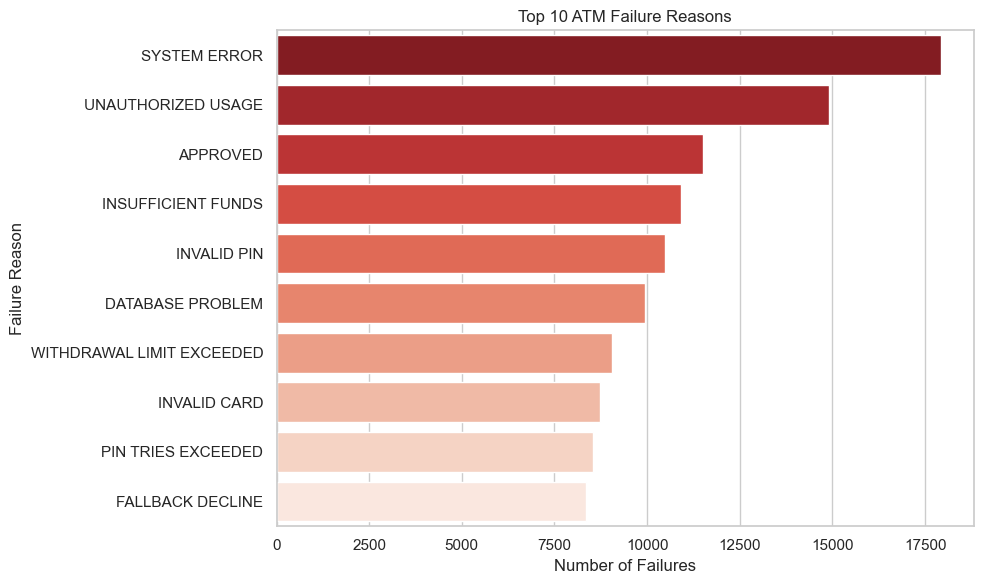

In [4]:
# Define failure keywords safely
atm_df['STATUS'] = atm_df['STATUS'].fillna('').str.upper()
atm_failed = atm_df[atm_df['STATUS'].str.contains('FAILED')]

# Clean and map Response Codes
code_descriptions = {
    0: 'APPROVED', 50: 'UNAUTHORIZED USAGE', 51: 'EXPIRED CARD', 510: 'EXPIRED CARD',
    52: 'INVALID CARD', 53: 'INVALID PIN', 54: 'DATABASE PROBLEM',
    55: 'INELIGIBLE TXN', 56: 'INELIGIBLE ACCOUNT', 57: 'TXN NOT SUPPORTED',
    59: 'INSUFFICIENT FUNDS', 60: 'LIMIT EXCEEDED', 61: 'WITHDRAWAL LIMIT EXCEEDED',
    62: 'PIN TRIES EXCEEDED', 68: 'EXTERNAL DECLINE', 70: 'SYSTEM ERROR',
    86: 'TVR DECLINE', 87: 'CRYPTOGRAM FAILURE', 88: 'FALLBACK DECLINE'
}

failed_codes = atm_failed.copy()
failed_codes['RESPONSE_CODE_CLEAN'] = pd.to_numeric(
    failed_codes['RESPONSE_CODE'].astype(str).str.extract(r'(\d{1,3})')[0], errors='coerce'
)
failed_codes = failed_codes.dropna(subset=['RESPONSE_CODE_CLEAN'])
failed_counts = failed_codes['RESPONSE_CODE_CLEAN'].astype(int).map(code_descriptions).value_counts().reset_index()
failed_counts.columns = ['DESCRIPTION', 'COUNT']

plt.figure(figsize=(10, 6))
sns.barplot(data=failed_counts.head(10), x='COUNT', y='DESCRIPTION', palette='Reds_r')
plt.title('Top 10 ATM Failure Reasons')
plt.xlabel('Number of Failures')
plt.ylabel('Failure Reason')
plt.tight_layout()
plt.show()

## 3. Advanced ATM Clustering (Machine Learning)
Previously, clustering was done strictly on Volume and Amount, which ignored the failure rate. Furthermore, the data is highly skewed, which K-Means struggles with. 

**Improvements implemented here:**
1. **Feature Engineering:** We calculated `FAILURE_RATE_PCT`.
2. **Log Transformation:** We apply `np.log1p()` to Volume and Amount to normalize the skewness so K-Means isn't ruined by a few massive outliers.
3. **Elbow Method:** We mathematically determine the optimal `K` clusters instead of guessing.
4. **Dynamic Ranking:** Clusters are sorted by their Performance Score so 'Low' always means Low.

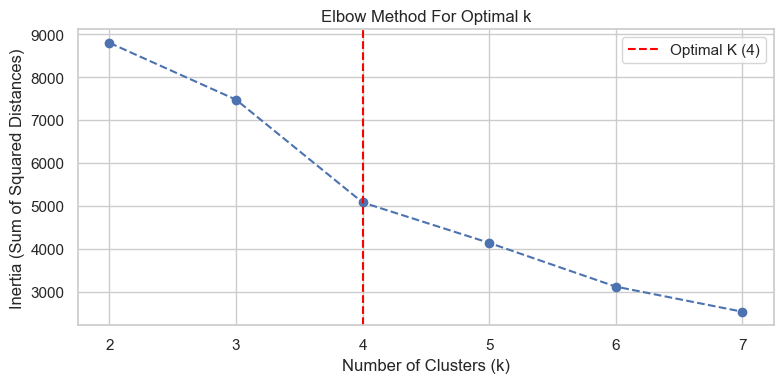

In [5]:
# 1. Feature Engineering
# Calculate total transactions and failures per terminal
atm_grouped = atm_df.groupby(['TERMINAL_ID', 'DISTRICTNAME']).agg(
    TOTAL_TXN=('NO_TXN', 'sum'),
    TOTAL_AMOUNT=('AMOUNT', 'sum')
).reset_index()

failed_txns = atm_df[atm_df['STATUS'].str.contains('FAILED')].groupby('TERMINAL_ID')['NO_TXN'].sum().reset_index()
failed_txns.columns = ['TERMINAL_ID', 'FAILED_TXN']

atm_cluster_df = atm_grouped.merge(failed_txns, on='TERMINAL_ID', how='left').fillna(0)

# Calculate Failure Rate Percentage
atm_cluster_df['FAILURE_RATE_PCT'] = (atm_cluster_df['FAILED_TXN'] / atm_cluster_df['TOTAL_TXN'].replace(0, 1)) * 100

# 2. Log Transformation
atm_cluster_df['LOG_TXN'] = np.log1p(atm_cluster_df['TOTAL_TXN'])
atm_cluster_df['LOG_AMOUNT'] = np.log1p(atm_cluster_df['TOTAL_AMOUNT'])

# Select features for clustering
features = ['LOG_TXN', 'LOG_AMOUNT', 'FAILURE_RATE_PCT']
X = atm_cluster_df[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Elbow Method to find optimal K
inertia = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.axvline(x=4, color='red', linestyle='--', label='Optimal K (4)')
plt.legend()
plt.tight_layout()
plt.show()

### 3.1 Applying K-Means & Dynamic Ranking
We will proceed with 4 clusters. We will score each cluster based on its average Transaction Volume to guarantee that 'Low', 'Moderate', 'High', and 'Very High' are assigned correctly.

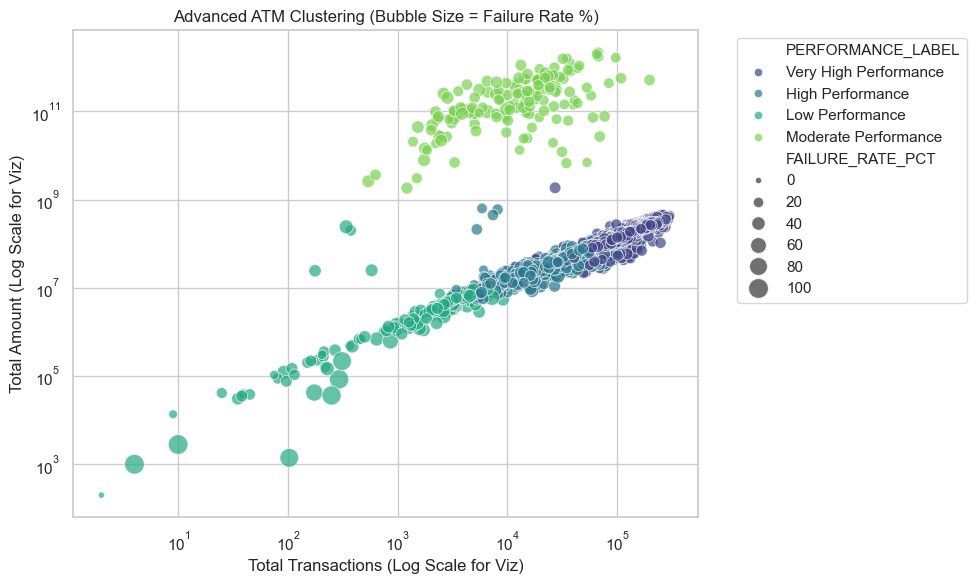

In [6]:
# Fit K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
atm_cluster_df['CLUSTER'] = kmeans.fit_predict(X_scaled)

# 4. Dynamic Cluster Ranking
cluster_summary = atm_cluster_df.groupby('CLUSTER')['TOTAL_TXN'].mean().reset_index()
cluster_summary = cluster_summary.sort_values('TOTAL_TXN').reset_index(drop=True)

# Map sorted indices to labels
labels = ['Low Performance', 'Moderate Performance', 'High Performance', 'Very High Performance']
mapping_dict = {cluster: label for cluster, label in zip(cluster_summary['CLUSTER'], labels)}

atm_cluster_df['PERFORMANCE_LABEL'] = atm_cluster_df['CLUSTER'].map(mapping_dict)

# Visualize Advanced Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=atm_cluster_df, 
    x='TOTAL_TXN', 
    y='TOTAL_AMOUNT', 
    hue='PERFORMANCE_LABEL', 
    size='FAILURE_RATE_PCT',
    sizes=(20, 200),
    palette='viridis', 
    alpha=0.7
)
plt.yscale('log')
plt.xscale('log')
plt.title('Advanced ATM Clustering (Bubble Size = Failure Rate %)')
plt.xlabel('Total Transactions (Log Scale for Viz)')
plt.ylabel('Total Amount (Log Scale for Viz)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3.2 Actionable Business Insights
Because we included `FAILURE_RATE_PCT`, we can identify critical anomalies: **High Performance Terminals with massive Failure Rates.** These are terminals processing millions in cash but frustrating a huge percentage of users. They require immediate IT intervention.

In [7]:
# Identify Critical Maintenance Terminals
critical_atms = atm_cluster_df[
    (atm_cluster_df['PERFORMANCE_LABEL'].isin(['High Performance', 'Very High Performance'])) & 
    (atm_cluster_df['FAILURE_RATE_PCT'] > 20) # Failure rate greater than 20%
].sort_values('FAILURE_RATE_PCT', ascending=False)

print(f"Found {len(critical_atms)} High-Performance ATMs with >20% Failure Rates!")
critical_atms[['TERMINAL_ID', 'DISTRICTNAME', 'TOTAL_TXN', 'FAILURE_RATE_PCT', 'PERFORMANCE_LABEL']].head(10)

Found 3863 High-Performance ATMs with >20% Failure Rates!


,TERMINAL_ID,DISTRICTNAME,TOTAL_TXN,FAILURE_RATE_PCT,PERFORMANCE_LABEL
3822,AWL00055,WOLDIA,28917,50.793651,High Performance
2736,AMG00015,MEGENAGNA,45483,46.868061,High Performance
583,ABD00140,BAHIR DAR,15150,46.594059,High Performance
1528,AGD00169,GONDER,44871,46.208019,High Performance
1954,AHW00225,HAWASSA,84980,45.203577,High Performance
1914,AHW00184,HAWASSA,67429,45.007341,High Performance
2004,AJJ00046,JIJIGA,29622,44.152994,High Performance
621,ABD00208,BAHIR DAR,11762,44.082639,High Performance
1406,ADM00077,DEBRE MARKOS,29487,43.649744,High Performance
1476,AGD00093,GONDER,19875,43.577358,High Performance


## 4. POS Terminal Analysis & Clustering
We now apply the identical rigorous Data Science pipeline to the POS devices.

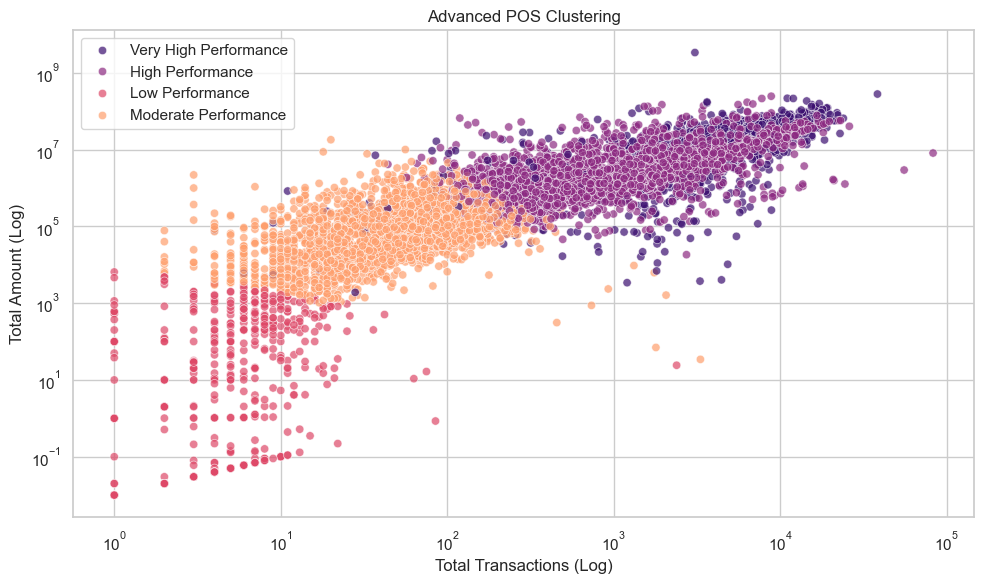

In [8]:
# Handle POS Data
pos_df['STATUS'] = pos_df['STATUS'].fillna('').str.upper()

pos_grouped = pos_df.groupby(['TERMINAL_ID', 'DISTRICTNAME']).agg(
    TOTAL_TXN=('NO_TRXN', 'sum'),
    TOTAL_AMOUNT=('TOTAL_AMOUNT', 'sum')
).reset_index()

pos_failed = pos_df[pos_df['STATUS'].str.contains('FAILED')].groupby('TERMINAL_ID')['NO_TRXN'].sum().reset_index()
pos_failed.columns = ['TERMINAL_ID', 'FAILED_TXN']

pos_cluster_df = pos_grouped.merge(pos_failed, on='TERMINAL_ID', how='left').fillna(0)
pos_cluster_df['FAILURE_RATE_PCT'] = (pos_cluster_df['FAILED_TXN'] / pos_cluster_df['TOTAL_TXN'].replace(0, 1)) * 100

# Transform
pos_cluster_df['LOG_TXN'] = np.log1p(pos_cluster_df['TOTAL_TXN'])
pos_cluster_df['LOG_AMOUNT'] = np.log1p(pos_cluster_df['TOTAL_AMOUNT'])

# Scale & Cluster
X_pos = pos_cluster_df[['LOG_TXN', 'LOG_AMOUNT', 'FAILURE_RATE_PCT']]
X_pos_scaled = StandardScaler().fit_transform(X_pos)

kmeans_pos = KMeans(n_clusters=4, random_state=42)
pos_cluster_df['CLUSTER'] = kmeans_pos.fit_predict(X_pos_scaled)

# Dynamic Ranking
pos_summary = pos_cluster_df.groupby('CLUSTER')['TOTAL_TXN'].mean().reset_index().sort_values('TOTAL_TXN')
pos_mapping = {cluster: label for cluster, label in zip(pos_summary['CLUSTER'], labels)}
pos_cluster_df['PERFORMANCE_LABEL'] = pos_cluster_df['CLUSTER'].map(pos_mapping)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pos_cluster_df, x='TOTAL_TXN', y='TOTAL_AMOUNT', 
    hue='PERFORMANCE_LABEL', palette='magma', alpha=0.7
)
plt.yscale('log')
plt.xscale('log')
plt.title('Advanced POS Clustering')
plt.xlabel('Total Transactions (Log)')
plt.ylabel('Total Amount (Log)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Report Exports
Finally, we export the analyzed datasets to structured Excel workbooks. The data inside these exports is fully anonymized and ready to be handed off to management or IT teams.

In [9]:
# Ensure export directory exists
os.makedirs("Advanced_Reports", exist_ok=True)

# ATM Export
atm_export = atm_cluster_df[['TERMINAL_ID', 'DISTRICTNAME', 'TOTAL_TXN', 'TOTAL_AMOUNT', 'FAILURE_RATE_PCT', 'PERFORMANCE_LABEL']]
atm_export.to_excel("Advanced_Reports/Anonymized_ATM_Performance_Report.xlsx", index=False)

# POS Export 
pos_export = pos_cluster_df[['TERMINAL_ID', 'DISTRICTNAME', 'TOTAL_TXN', 'TOTAL_AMOUNT', 'FAILURE_RATE_PCT', 'PERFORMANCE_LABEL']]
pos_export.to_excel("Advanced_Reports/Anonymized_POS_Performance_Report.xlsx", index=False)

print("✅ Advanced Anonymized Reports successfully exported to 'Advanced_Reports' folder.")

✅ Advanced Anonymized Reports successfully exported to 'Advanced_Reports' folder.
